In [31]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,y):
    return np.array([y[1], -4*np.sin(2*x)])

def solve_rk(f, x_init, x_end, y_init, h0, tol, alpha):
    n, m = 0, 0
    x_list = [x_init]
    y_list = [y_init]
    h_list = []

    x = x_init
    y = np.array(y_init)
    h = h0

    k1 = f(x, y)

    while x < x_end:
        n += 1
        
        if x + h > x_end:
            h = x_end - x

        k2 = f(x + h/2, y + h*k1/2)
        k3 = f(x + 3*h/4, y + 3*h*k2/4)

        y_next = y + h*(2*k1 + 3*k2 + 4*k3)/9
        k4 = f(x + h, y_next)
        
        z_next = y + h*(7*k1 + 6*k2 + 8*k3 + 3*k4)/24
        est = np.linalg.norm(y_next - z_next)

        if est < tol:
            m += 1
            x += h
            y = z_next ## y eller z?

            x_list.append(x)
            y_list.append(y)
            h_list.append(h)

            k1 = k4

        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    return np.array(x_list), np.array(y_list), np.array(h_list), n, m

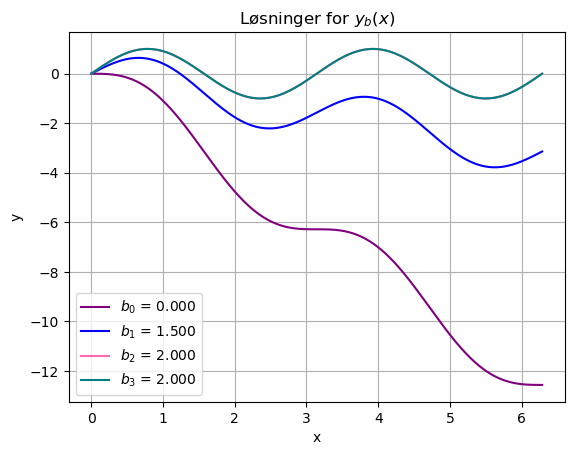

In [40]:
def secant_root(g, z0, z1, tol):
    max_iteratrions = 1000
    roots = [z0, z1]

    for i in range(max_iteratrions):
        if np.abs(z0 - z1) < tol:
            return roots

        z = (z0 * g(z1) - z1 * g(z0)) / (g(z1) - g(z0))
        z0, z1 = z1, z
        roots.append(z1)

    raise ValueError(f"Konvgergerer ikke etter {max_iteratrions} iterasjoner")

def g(b):
    x_init = 0
    x_end = 2*np.pi
    y_init = [0, b]
    h0 = 1e-2
    tol_g = 1e-7
    alpha = 0.8

    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol_g, alpha)

    return y_vals[-1, 0]  #x[-1] = 2pi, 

#gjett
b0 = 0.0
b1 = 1.5

b_values = secant_root(g, b0, b1, tol=1e-8)

x_init = 0
x_end = 2*np.pi
h0 = 1e-2
tol_g = 1e-7
alpha = 0.8

colors = ["purple", "blue", "hotpink", "teal"]
for i, b in enumerate(b_values):
    y_init = [0, b]
    x_vals, y_vals, h_vals, n, m = solve_rk(f, x_init, x_end, y_init, h0, tol_g, alpha)
    plt.plot(x_vals, y_vals[:, 0], label = f"$b_{i}$ = {b:.3f}", color=colors[i % len(colors)])


plt.grid()
plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Løsninger for $y_b(x)$")
plt.legend()
plt.show()

Ved å bruke sekantmetoden er det mulig å løse samme problem som i 1a) uten å kjenne til verdian av $y'(x_{init})$. Ved å gi to intielle gjett for b-verdiene $b_0$ og $b_1$, justerer sekantmetoden $b$ for å tilfredstille randbetingelsene. Etter få iterasjoner er verdien av $b$ lik, altså konvergerer kurvene mot en løsning. De to siste kruvene er nesten identiske med et lite avvik av størrelsesorden $10^{-10}$ som vises i plottet under. 

noe om skytemetoden???

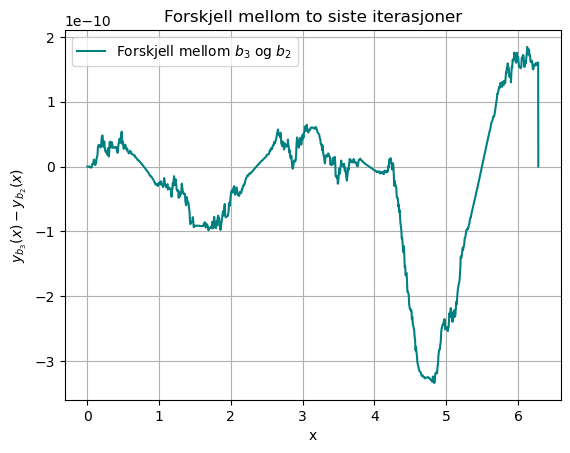

In [45]:
y_init_b3 = [0, b_values[-1]]
y_init_b2 = [0, b_values[-2]]

x_vals, y_b3, h, n, m = solve_rk(f, x_init, x_end, y_init_b3, h0, tol_g, alpha)
x_vals, y_b2, h, n, m = solve_rk(f, x_init, x_end, y_init_b2, h0, tol_g, alpha)

diff = y_b3[:, 0] - y_b2[:, 0]

plt.plot(x_vals, diff, label="Forskjell mellom $b_3$ og $b_2$", color = "teal")
plt.grid()
plt.xlabel("x")
plt.ylabel(r"$y_{b_3}(x) - y_{b_{2}}(x)$")
plt.title("Forskjell mellom to siste iterasjoner")
plt.legend()
plt.show()